In [165]:
import pandas as pd
import numpy as np

In [166]:
path_data = "./data/houses_Madrid.csv"

In [242]:
df = pd.read_csv(path_data, index_col=0)

In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21742 entries, 0 to 21741
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            21742 non-null  int64  
 1   title                         21742 non-null  str    
 2   subtitle                      21742 non-null  str    
 3   sq_mt_built                   21616 non-null  float64
 4   sq_mt_useful                  8228 non-null   float64
 5   n_rooms                       21742 non-null  int64  
 6   n_bathrooms                   21726 non-null  float64
 7   n_floors                      1437 non-null   float64
 8   sq_mt_allotment               1432 non-null   float64
 9   latitude                      0 non-null      float64
 10  longitude                     0 non-null      float64
 11  raw_address                   16277 non-null  str    
 12  is_exact_address_hidden       21742 non-null  bool   
 13  street_name 

In [169]:
df.describe()

,id,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,longitude,portal,...,rent_price_by_area,buy_price,buy_price_by_area,built_year,are_pets_allowed,is_furnished,is_kitchen_equipped,has_private_parking,has_public_parking,parking_price
count,21742.000000,21616.000000,8228.000000,21742.000000,21726.000000,1437.000000,1432.000000,0.0,0.0,0.0,...,0.0,2.174200e+04,21742.000000,10000.000000,0.0,0.0,0.0,0.0,0.0,7719.000000
mean,10871.500000,146.920892,103.458192,3.005749,2.091687,3.128740,241.692737,NaN,NaN,NaN,...,NaN,6.537356e+05,4020.523871,1970.046400,NaN,NaN,NaN,NaN,NaN,2658.000518
std,6276.519112,134.181865,88.259192,1.510497,1.406992,0.907713,247.484853,NaN,NaN,NaN,...,NaN,7.820821e+05,1908.418774,69.386705,NaN,NaN,NaN,NaN,NaN,13360.966258
min,1.000000,13.000000,1.000000,0.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,...,NaN,3.600000e+04,447.000000,1723.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,5436.250000,70.000000,59.000000,2.000000,1.000000,2.000000,2.000000,NaN,NaN,NaN,...,NaN,1.980000e+05,2551.000000,1957.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,10871.500000,100.000000,79.000000,3.000000,2.000000,3.000000,232.000000,NaN,NaN,NaN,...,NaN,3.750000e+05,3720.000000,1970.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,16306.750000,162.000000,113.000000,4.000000,2.000000,4.000000,354.000000,NaN,NaN,NaN,...,NaN,7.636000e+05,5000.000000,1994.000000,NaN,NaN,NaN,NaN,NaN,0.000000
max,21742.000000,999.000000,998.000000,24.000000,16.000000,7.000000,997.000000,NaN,NaN,NaN,...,NaN,8.800000e+06,18889.000000,8170.000000,NaN,NaN,NaN,NaN,NaN,600000.000000


In [170]:
df.isna().sum()[df.isna().sum() != 0]

sq_mt_built                       126
sq_mt_useful                    13514
n_bathrooms                        16
n_floors                        20305
sq_mt_allotment                 20310
latitude                        21742
longitude                       21742
raw_address                      5465
street_name                      5905
street_number                   15442
portal                          21742
floor                            2607
is_floor_under                   1170
door                            21742
rent_price_by_area              21742
house_type_id                     391
is_new_development                992
built_year                      11742
has_central_heating              8134
has_individual_heating           8134
are_pets_allowed                21742
has_ac                          10531
has_fitted_wardrobes             8343
has_lift                         2386
is_exterior                      3043
has_garden                      20186
has_pool    

In [171]:
df['is_buy_price_known'].isna().sum()

np.int64(0)

In [172]:
df[['buy_price_by_area', 'built_year']]

,buy_price_by_area,built_year
0,1328,1960.0
1,1856,NaN
2,1535,NaN
3,1717,1955.0
4,2407,2003.0
...,...,...
21737,4487,2020.0
21738,4427,2002.0
21739,3886,2002.0
21740,2405,1981.0


In [173]:
df['built_year'] = df['built_year'].apply(lambda x: x - x%5)

In [174]:
df = df.dropna(subset=['buy_price_by_area', 'built_year'])
growth = df[['buy_price_by_area', 'built_year']].groupby('built_year').mean().reset_index()

In [175]:
df = df[df["built_year"] < 2021]

In [241]:
df

,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True
5,21737,Piso en venta en geologia,"San Andrés, Madrid",126.0,114.0,4,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,False,False,False,True
9,21733,Piso en venta en calle de Martinez Oviol,"Los Rosales, Madrid",85.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,Casa o chalet independiente en venta en aveni...,"Campo de las Naciones-Corralejos, Madrid",267.0,215.0,5,3.0,2.0,382.0,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True
21737,5,Ático en venta en Casco Histórico de Barajas,"Barajas, Madrid",78.0,NaN,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,NaN,NaN,NaN,NaN
21738,4,Piso en venta en Urb. Campo de las Naciones - ...,"Barajas, Madrid",96.0,83.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,False,True,True,True
21739,3,Piso en venta en Campo de las Naciones-Corralejos,"Barajas, Madrid",175.0,NaN,4,2.0,NaN,NaN,NaN,...,E,True,NaN,NaN,True,0.0,NaN,NaN,NaN,NaN


### Preprocessing

1. Drop with treshhold 
2. Drop columns with correlation threshhold 
3. Drop: Title, street_name, street_number,
4. Neihgborhood_id (Neighborhood 132: Los Ángeles (1796.68 €/m2) - District 21: Villaverde) numeric extraction, 
5. built_year > 1850 leave other drop
6. "has_central_heating"", "has_ac", "has_fitted_wardrobes", "has_lift", "is_exterior", "has_pool", "has_terrace", "has_garden", "has_balcony", "has_storage_room", "is_accessible", 
"has_green_zones" fill with group by built_year, 
7. fill with most common: "is_orientation_north"
-- 

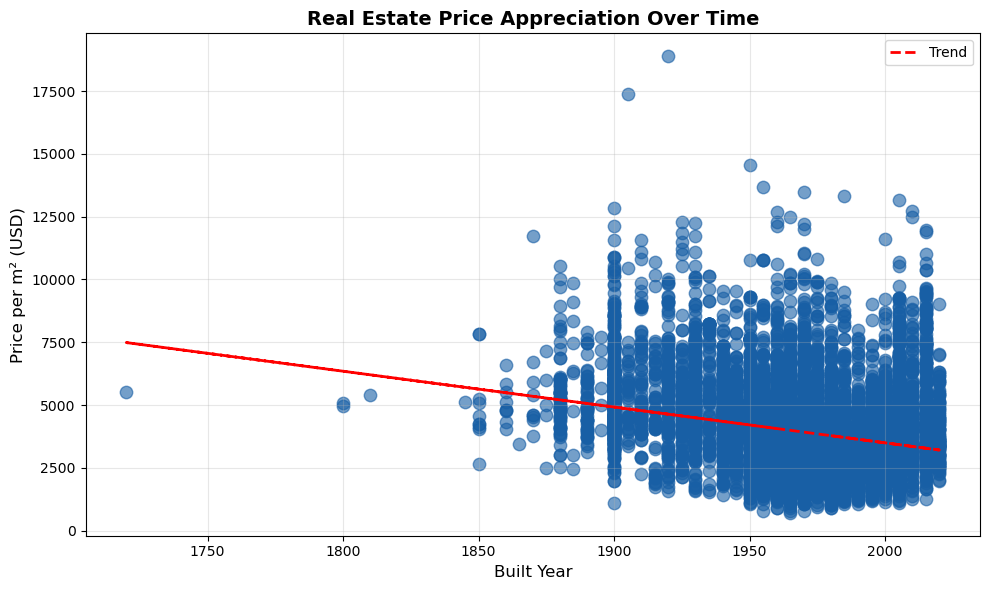

In [177]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['built_year'], df['buy_price_by_area'], alpha=0.6, s=80, color='#185FA5')

z = np.polyfit(df['built_year'], df['buy_price_by_area'], 1)
p = np.poly1d(z)
ax.plot(df['built_year'], p(df['built_year']), 'r--', linewidth=2, label='Trend')

ax.set_xlabel('Built Year', fontsize=12)
ax.set_ylabel('Price per m² (USD)', fontsize=12)
ax.set_title('Real Estate Price Appreciation Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [178]:
df['is_buy_price_known']

0        True
3        True
4        True
5        True
9        True
         ... 
21733    True
21737    True
21738    True
21739    True
21740    True
Name: is_buy_price_known, Length: 9999, dtype: bool

In [179]:
import plotly.express as px

def plot_price_growth(df):
    """
    Plot real estate price growth over 5-year bins without modifying original df.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain 'is_buy_price_known', 'buy_price_by_area', 'built_year' columns
    """
    # Create a copy to avoid modifying original
    df_filtered = df.copy()
    
    # Apply filters
    df_filtered = df_filtered[df_filtered['is_buy_price_known'] == True]
    df_filtered = df_filtered[['buy_price_by_area', 'built_year']].dropna()
    df_filtered = df_filtered[(df_filtered['built_year'] >= 1800) & 
                               (df_filtered['built_year'] <= 2020)]
    
    # Bin to 5-year intervals
    df_filtered['built_year'] = df_filtered['built_year'].apply(lambda x: x - x%5)
    
    # Aggregate
    growth = df_filtered.groupby('built_year').mean().reset_index()
    
    # Plot
    fig = px.scatter(
        growth, 
        x='built_year', 
        y='buy_price_by_area', 
        size='buy_price_by_area',
        color='buy_price_by_area',
        title='Growth of Buy Price by Area Every 5 Years',
        labels={'built_year': 'Year', 'buy_price_by_area': 'Buy Price by Area'},
        template='plotly_dark'
    )
    
    return fig

# Usage
fig = plot_price_growth(df)
fig.show()

# Original df is unchanged
print(df.shape)  # Same as before

(9999, 57)


In [180]:
target=df[df['is_buy_price_known']==True]
target=target['buy_price']
target.describe()

count    9.999000e+03
mean     6.553159e+05
std      7.737880e+05
min      3.600000e+04
25%      1.950000e+05
50%      3.750000e+05
75%      7.800000e+05
max      8.700000e+06
Name: buy_price, dtype: float64

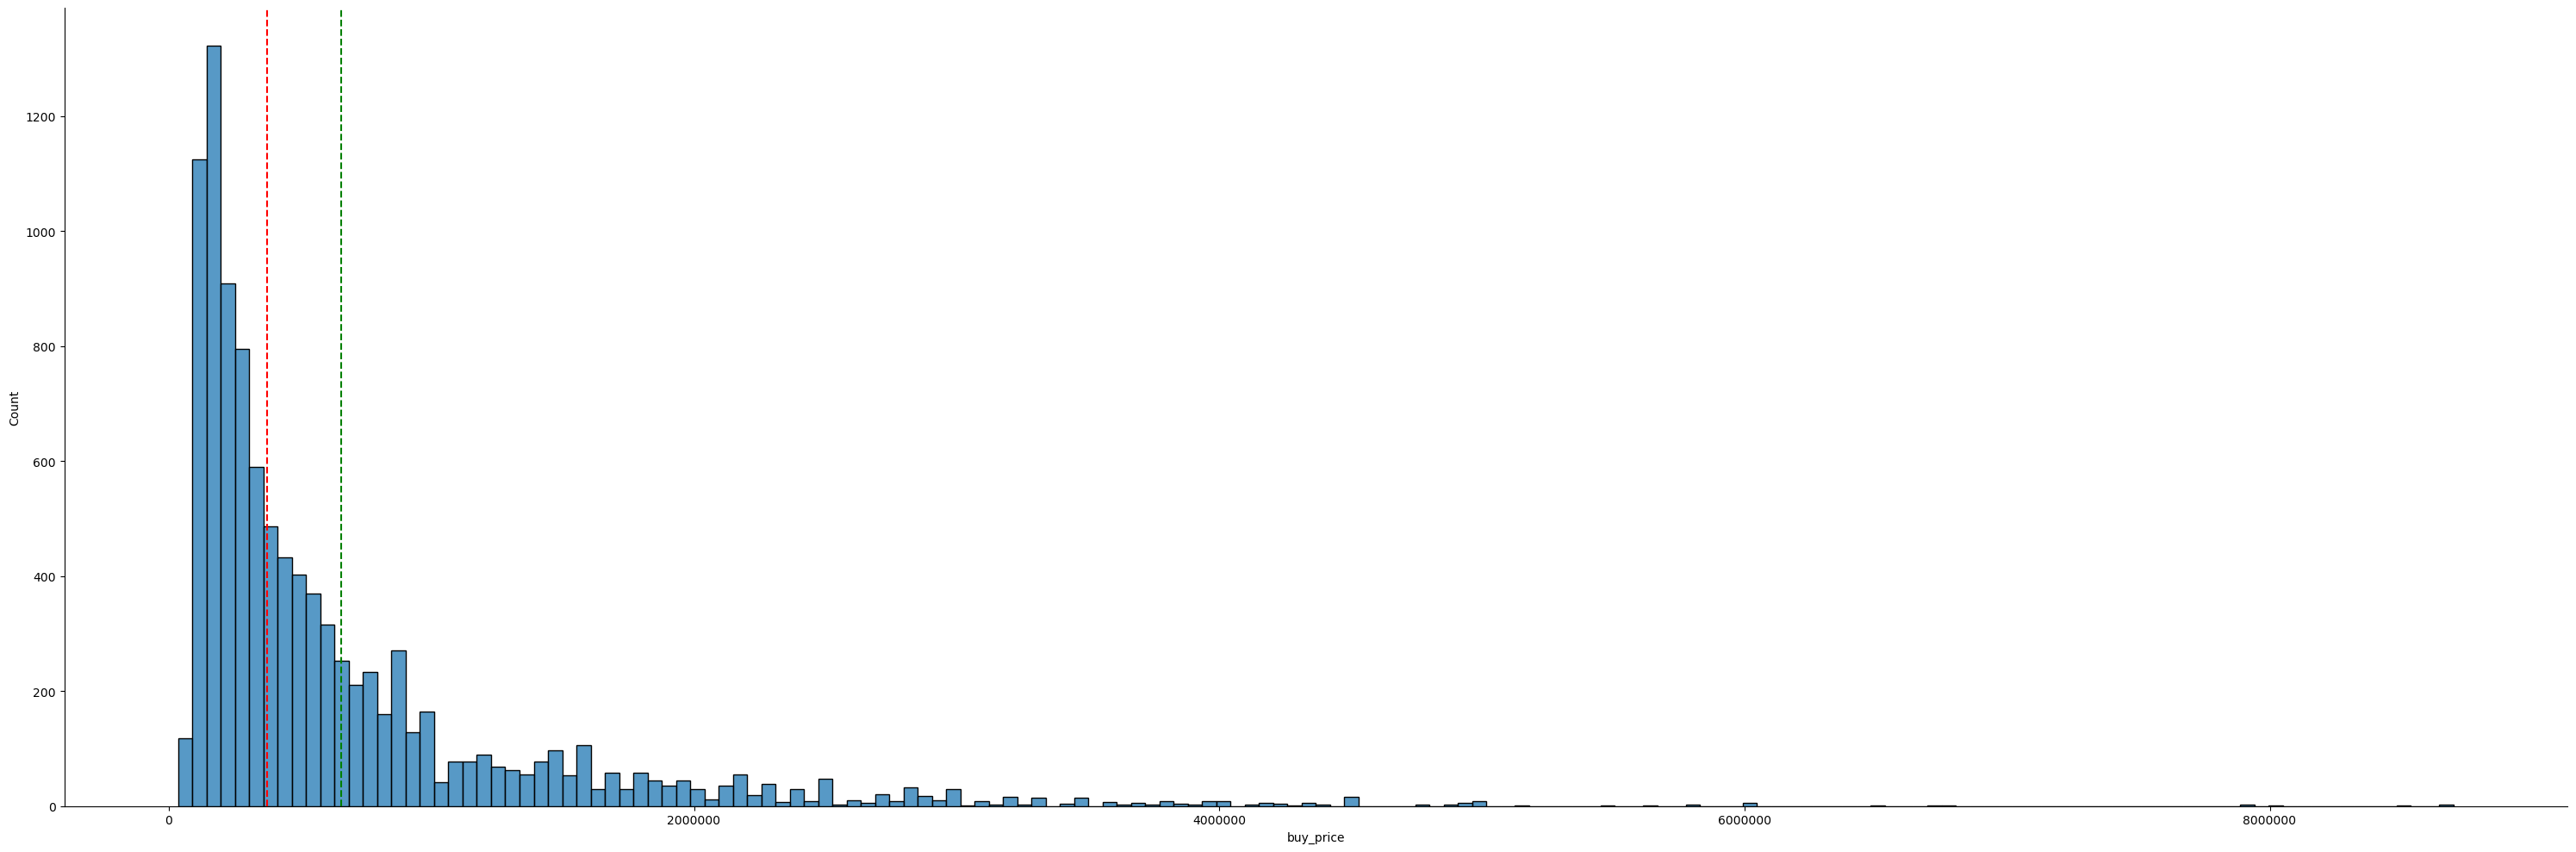

In [181]:
import seaborn as sns

#plt.figure(figsize=(12, 10))
sns.displot(x=target, height=10, aspect=3)
plt.ticklabel_format(style='plain', axis='x')
plt.axvline(target.mean(), color='g', linestyle='--', label='Mean')
plt.axvline(target.median(), color='r', linestyle='--', label='Median')


In [182]:
print("Skewness: %f" % target.skew())
print("Kurtosis: %f" % target.kurt())

Skewness: 3.214742
Kurtosis: 15.833622


In [183]:
def curate_df(df, missing_threshold=0.5):
    """
    Remove columns with missing value ratio exceeding threshold.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    missing_threshold : float, default 0.5
        Drop columns where missing values > this fraction (0.5 = 50%)
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with sparse columns removed
    
    Example:
    --------
    df_clean = curate_df(df, missing_threshold=0.5)
    """
    df_copy = df.copy()
    
    # Calculate missing ratio per column
    missing_ratio = df_copy.isna().sum() / len(df_copy)
    
    # Identify columns exceeding threshold
    cols_to_drop = missing_ratio[missing_ratio > missing_threshold].index.tolist()
    
    # Report what's being dropped
    if cols_to_drop:
        print(f"Dropping {len(cols_to_drop)} columns with >{missing_threshold*100:.0f}% missing:")
        for col in cols_to_drop:
            print(f"  • {col}: {missing_ratio[col]*100:.1f}% missing")
    else:
        print(f"No columns exceed {missing_threshold*100:.0f}% missing threshold")
    
    # Drop and return
    df_curated = df_copy.drop(columns=cols_to_drop)
    
    print(f"\nShape: {df.shape} → {df_curated.shape}")
    
    return df_curated

# Usage
df_curated = curate_df(df, missing_threshold=0.5)

Dropping 23 columns with >50% missing:
  • sq_mt_useful: 52.0% missing
  • n_floors: 92.0% missing
  • sq_mt_allotment: 91.9% missing
  • latitude: 100.0% missing
  • longitude: 100.0% missing
  • street_number: 80.6% missing
  • portal: 100.0% missing
  • door: 100.0% missing
  • rent_price_by_area: 100.0% missing
  • are_pets_allowed: 100.0% missing
  • has_garden: 91.5% missing
  • has_pool: 76.1% missing
  • has_terrace: 55.6% missing
  • has_balcony: 82.2% missing
  • has_storage_room: 63.9% missing
  • is_furnished: 100.0% missing
  • is_kitchen_equipped: 100.0% missing
  • is_accessible: 75.2% missing
  • has_green_zones: 80.5% missing
  • has_private_parking: 100.0% missing
  • has_public_parking: 100.0% missing
  • is_parking_included_in_price: 63.8% missing
  • parking_price: 63.8% missing

Shape: (9999, 57) → (9999, 34)


<Axes: >

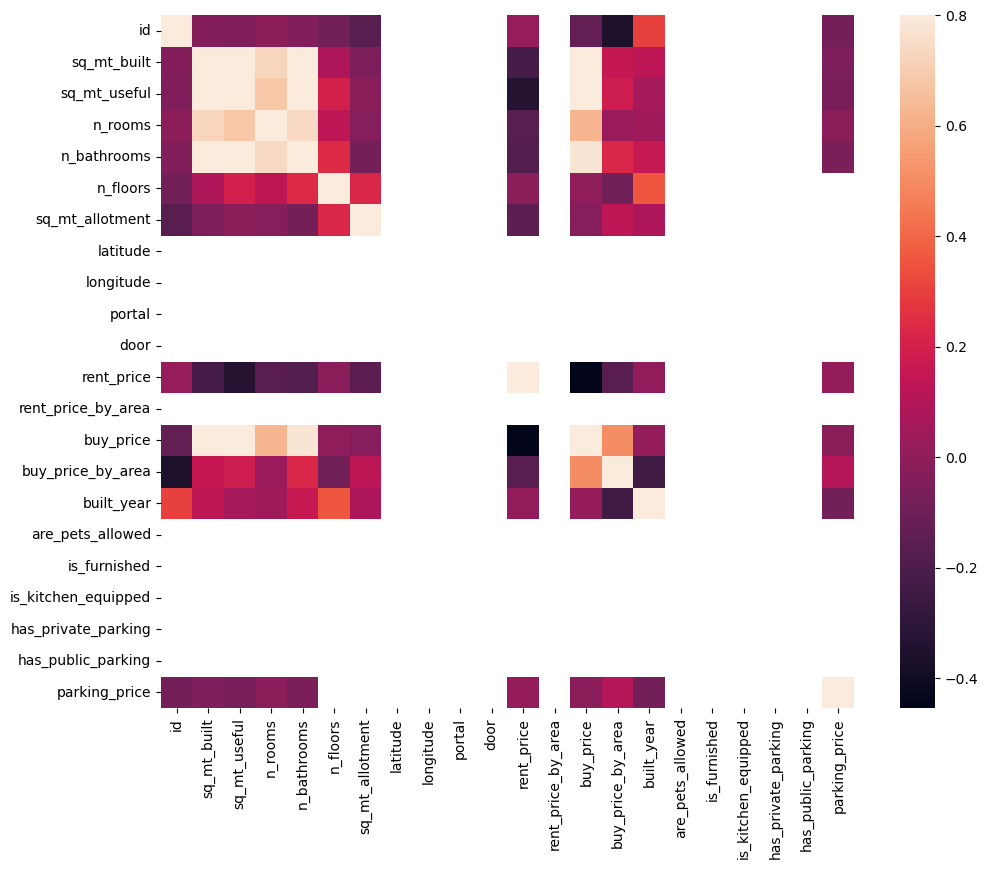

In [184]:
df_numeric = df.select_dtypes(include=['number'])
corrmat = df_numeric.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

In [185]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/total)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(50)

,Total,Percent
has_public_parking,9999,1.0
door,9999,1.0
rent_price_by_area,9999,1.0
portal,9999,1.0
has_private_parking,9999,1.0
longitude,9999,1.0
latitude,9999,1.0
is_kitchen_equipped,9999,1.0
are_pets_allowed,9999,1.0
is_furnished,9999,1.0


In [186]:
dftrim=df.drop(columns=['title','has_public_parking','portal','are_pets_allowed','is_furnished','is_kitchen_equipped','rent_price_by_area','latitude','longitude','has_private_parking','door','street_number','street_name','raw_address','is_exact_address_hidden','rent_price','is_rent_price_known','is_buy_price_known'], errors="ignore")
dftrim

,id,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,floor,is_floor_under,...,is_accessible,has_green_zones,energy_certificate,has_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,3,False,...,NaN,NaN,D,False,NaN,NaN,False,True,False,False
3,21739,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,Bajo,True,...,True,NaN,en trámite,False,NaN,NaN,False,False,True,False
4,21738,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,4,False,...,NaN,True,en trámite,True,True,0.0,True,True,True,True
5,21737,"San Andrés, Madrid",126.0,114.0,4,2.0,NaN,NaN,3,False,...,True,NaN,en trámite,True,True,0.0,False,False,False,True
9,21733,"Los Rosales, Madrid",85.0,NaN,2,1.0,NaN,NaN,7,False,...,NaN,NaN,en trámite,False,NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,"Campo de las Naciones-Corralejos, Madrid",267.0,215.0,5,3.0,2.0,382.0,NaN,False,...,NaN,NaN,en trámite,True,True,0.0,True,True,True,True
21737,5,"Barajas, Madrid",78.0,NaN,2,2.0,NaN,NaN,4,False,...,NaN,NaN,en trámite,True,True,0.0,NaN,NaN,NaN,NaN
21738,4,"Barajas, Madrid",96.0,83.0,2,2.0,NaN,NaN,3,False,...,NaN,True,en trámite,True,True,0.0,False,True,True,True
21739,3,"Barajas, Madrid",175.0,NaN,4,2.0,NaN,NaN,Bajo,True,...,NaN,NaN,E,True,True,0.0,NaN,NaN,NaN,NaN


In [187]:
df

,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True
5,21737,Piso en venta en geologia,"San Andrés, Madrid",126.0,114.0,4,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,False,False,False,True
9,21733,Piso en venta en calle de Martinez Oviol,"Los Rosales, Madrid",85.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,Casa o chalet independiente en venta en aveni...,"Campo de las Naciones-Corralejos, Madrid",267.0,215.0,5,3.0,2.0,382.0,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True
21737,5,Ático en venta en Casco Histórico de Barajas,"Barajas, Madrid",78.0,NaN,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,NaN,NaN,NaN,NaN
21738,4,Piso en venta en Urb. Campo de las Naciones - ...,"Barajas, Madrid",96.0,83.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,False,True,True,True
21739,3,Piso en venta en Campo de las Naciones-Corralejos,"Barajas, Madrid",175.0,NaN,4,2.0,NaN,NaN,NaN,...,E,True,NaN,NaN,True,0.0,NaN,NaN,NaN,NaN


In [188]:
dftrim.dtypes
for col in dftrim:
    print(dftrim[col].value_counts())
    print('')

id
21742    1
21739    1
21738    1
21737    1
21733    1
        ..
9        1
5        1
4        1
3        1
2        1
Name: count, Length: 9999, dtype: int64

subtitle
Moncloa, Madrid                             362
Chamartín, Madrid                           353
Hortaleza, Madrid                           325
Chamberí, Madrid                            268
Centro, Madrid                              260
                                           ... 
Horcajo, Madrid                               5
El Pardo, Madrid                              4
Casco Histórico de Barajas, Madrid            4
Timón, Madrid                                 4
Campo de las Naciones-Corralejos, Madrid      3
Name: count, Length: 145, dtype: int64

sq_mt_built
60.0     199
70.0     198
80.0     183
65.0     163
75.0     157
        ... 
706.0      1
259.0      1
389.0      1
595.0      1
427.0      1
Name: count, Length: 604, dtype: int64

sq_mt_useful
60.0     134
80.0     115
90.0     114
70.0     11

The following variables only have True, which means NaN is (probably) False and we can replace it with False:

has_ac
has_fitted_wardrobes
has_lift
is_exterior
has_garden
has_pool
has_terrace
has_balcony
has_storage_room
is_accessible
has_green_zones

In [189]:
dftrim["has_ac"]

0        True
3         NaN
4        True
5         NaN
9         NaN
         ... 
21733    True
21737    True
21738    True
21739    True
21740    True
Name: has_ac, Length: 9999, dtype: object

In [190]:
collist=['has_ac','has_fitted_wardrobes', "has_central_heating", "has_individual_heating"]
for col in collist:
    dftrim[col]=dftrim[col].fillna(False)
dftrim

,id,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,floor,is_floor_under,...,is_accessible,has_green_zones,energy_certificate,has_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,3,False,...,NaN,NaN,D,False,NaN,NaN,False,True,False,False
3,21739,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,Bajo,True,...,True,NaN,en trámite,False,NaN,NaN,False,False,True,False
4,21738,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,4,False,...,NaN,True,en trámite,True,True,0.0,True,True,True,True
5,21737,"San Andrés, Madrid",126.0,114.0,4,2.0,NaN,NaN,3,False,...,True,NaN,en trámite,True,True,0.0,False,False,False,True
9,21733,"Los Rosales, Madrid",85.0,NaN,2,1.0,NaN,NaN,7,False,...,NaN,NaN,en trámite,False,NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,"Campo de las Naciones-Corralejos, Madrid",267.0,215.0,5,3.0,2.0,382.0,NaN,False,...,NaN,NaN,en trámite,True,True,0.0,True,True,True,True
21737,5,"Barajas, Madrid",78.0,NaN,2,2.0,NaN,NaN,4,False,...,NaN,NaN,en trámite,True,True,0.0,NaN,NaN,NaN,NaN
21738,4,"Barajas, Madrid",96.0,83.0,2,2.0,NaN,NaN,3,False,...,NaN,True,en trámite,True,True,0.0,False,True,True,True
21739,3,"Barajas, Madrid",175.0,NaN,4,2.0,NaN,NaN,Bajo,True,...,NaN,NaN,E,True,True,0.0,NaN,NaN,NaN,NaN


In [191]:
total = dftrim.isnull().sum().sort_values(ascending=False)
percent = (dftrim.isnull().sum()/dftrim.isnull().count()).sort_values(ascending=True)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(40)

,Total,Percent
n_floors,9203,0.920392
sq_mt_allotment,9194,0.919492
has_garden,9146,0.914691
has_balcony,8221,0.822182
has_green_zones,8045,0.804580
has_pool,7609,0.760976
is_accessible,7518,0.751875
has_storage_room,6387,0.638764
parking_price,6379,0.637964
is_parking_included_in_price,6379,0.637964


In [192]:
dftrim.drop(columns=['is_orientation_east','is_orientation_south','is_orientation_west','is_orientation_north','has_individual_heating','has_central_heating','floor','is_floor_under','buy_price_by_area'], inplace=True)

In [193]:
dftrim.drop(columns=['sq_mt_allotment','sq_mt_useful','parking_price','is_parking_included_in_price','n_floors',], inplace=True, errors="ignore")

In [194]:
total = dftrim.isnull().sum().sort_values(ascending=False)
percent = (dftrim.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(10)

,Total,Percent
has_garden,9146.0,0.914691
has_balcony,8221.0,0.822182
has_green_zones,8045.0,0.804580
has_pool,7609.0,0.760976
is_accessible,7518.0,0.751875
has_storage_room,6387.0,0.638764
has_terrace,5564.0,0.556456
is_exterior,1425.0,0.142514
has_lift,1197.0,0.119712
is_new_development,398.0,0.039804


In [195]:
dftrim['district_id']=dftrim['neighborhood_id'].copy()
dftrim.district_id=dftrim.district_id.str.extract(r'(District \d+)')
dftrim.neighborhood_id=dftrim.neighborhood_id.str.extract(r'(Neighborhood \d+)')
dftrim.district_id=dftrim.district_id.str.extract(r'(\d+)')
dftrim.neighborhood_id=dftrim.neighborhood_id.str.extract(r'(\d+)')
dftrim

,id,subtitle,sq_mt_built,n_rooms,n_bathrooms,neighborhood_id,operation,buy_price,house_type_id,is_renewal_needed,...,has_garden,has_pool,has_terrace,has_balcony,has_storage_room,is_accessible,has_green_zones,energy_certificate,has_parking,district_id
0,21742,"San Cristóbal, Madrid",64.0,2,1.0,135,sale,85000,HouseType 1: Pisos,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,False,21
3,21739,"San Andrés, Madrid",64.0,2,1.0,134,sale,109900,HouseType 1: Pisos,False,...,NaN,NaN,NaN,NaN,True,True,NaN,en trámite,False,21
4,21738,"Los Rosales, Madrid",108.0,2,2.0,133,sale,260000,HouseType 1: Pisos,False,...,NaN,True,NaN,NaN,True,NaN,True,en trámite,True,21
5,21737,"San Andrés, Madrid",126.0,4,2.0,134,sale,195000,HouseType 1: Pisos,False,...,NaN,NaN,True,True,NaN,True,NaN,en trámite,True,21
9,21733,"Los Rosales, Madrid",85.0,2,1.0,133,sale,131400,HouseType 1: Pisos,True,...,NaN,NaN,True,NaN,NaN,NaN,NaN,en trámite,False,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,"Campo de las Naciones-Corralejos, Madrid",267.0,5,3.0,9,sale,790000,HouseType 2: Casa o chalet,False,...,True,True,True,NaN,True,NaN,NaN,en trámite,True,2
21737,5,"Barajas, Madrid",78.0,2,2.0,10,sale,350000,HouseType 5: Áticos,False,...,NaN,NaN,NaN,NaN,True,NaN,NaN,en trámite,True,2
21738,4,"Barajas, Madrid",96.0,2,2.0,9,sale,425000,HouseType 1: Pisos,False,...,NaN,True,NaN,NaN,True,NaN,True,en trámite,True,2
21739,3,"Barajas, Madrid",175.0,4,2.0,9,sale,680000,HouseType 1: Pisos,False,...,NaN,True,True,NaN,True,NaN,NaN,E,True,2


In [196]:
dftrim["district_id"].unique()

<ArrowStringArray>
['21', '19', '20', '18', '17', '14', '13', '11', '12', '10',  '8',  '9',  '6',
  '7',  '5',  '4',  '3', '15',  '1',  '2']
Length: 20, dtype: str

In [197]:
dftrim=dftrim[dftrim['sq_mt_built'].notna()]
dftrim=dftrim[dftrim['n_bathrooms'].notna()]

In [198]:
dftrim['house_type_id']=dftrim['house_type_id'].fillna("Misc")
mask=(dftrim['is_new_development'].isnull()) & (~dftrim['built_year'].isnull()) # fills missing values in is_new_development with False where build_year is unknown
dftrim['is_new_development'][mask]=False
dftrim.drop(columns='built_year',inplace=True)
dftrim['is_new_development'].value_counts()

/var/folders/m6/s_qkv9vs161g9w1bm3hxb69h0000gn/T/ipykernel_22480/2153494464.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  dftrim['is_new_development'][mask]=False


is_new_development
False    9541
Name: count, dtype: int64

In [199]:
dft1=dftrim.groupby(by='house_type_id')
dft1['is_exterior'].describe()

,count,unique,top,freq
house_type_id,,,,
HouseType 1: Pisos,7628,2,True,6812
HouseType 2: Casa o chalet,0,0,NaN,NaN
HouseType 4: Dúplex,304,2,True,289
HouseType 5: Áticos,447,2,True,441
Misc,188,2,True,138


In [200]:
dffinal=dftrim.drop(columns=["neighborhood_id"])
dffinal['has_lift']=pd.to_numeric(dffinal['has_lift'],errors='coerce')
dffinal['is_exterior']=pd.to_numeric(dffinal['is_exterior'],errors='coerce')
dffinal=pd.get_dummies(dffinal)
dffinal=dffinal.drop(columns=["district_id_21"])
dffinal

,id,sq_mt_built,n_rooms,n_bathrooms,buy_price,is_renewal_needed,has_lift,is_exterior,has_parking,"subtitle_12 de Octubre-Orcasur, Madrid",...,district_id_19,district_id_2,district_id_20,district_id_3,district_id_4,district_id_5,district_id_6,district_id_7,district_id_8,district_id_9
0,21742,64.0,2,1.0,85000,False,0.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,21739,64.0,2,1.0,109900,False,1.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,21738,108.0,2,2.0,260000,False,1.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False
5,21737,126.0,4,2.0,195000,False,0.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False
9,21733,85.0,2,1.0,131400,True,0.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,267.0,5,3.0,790000,False,NaN,NaN,True,False,...,False,True,False,False,False,False,False,False,False,False
21737,5,78.0,2,2.0,350000,False,1.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False
21738,4,96.0,2,2.0,425000,False,1.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False
21739,3,175.0,4,2.0,680000,False,0.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False


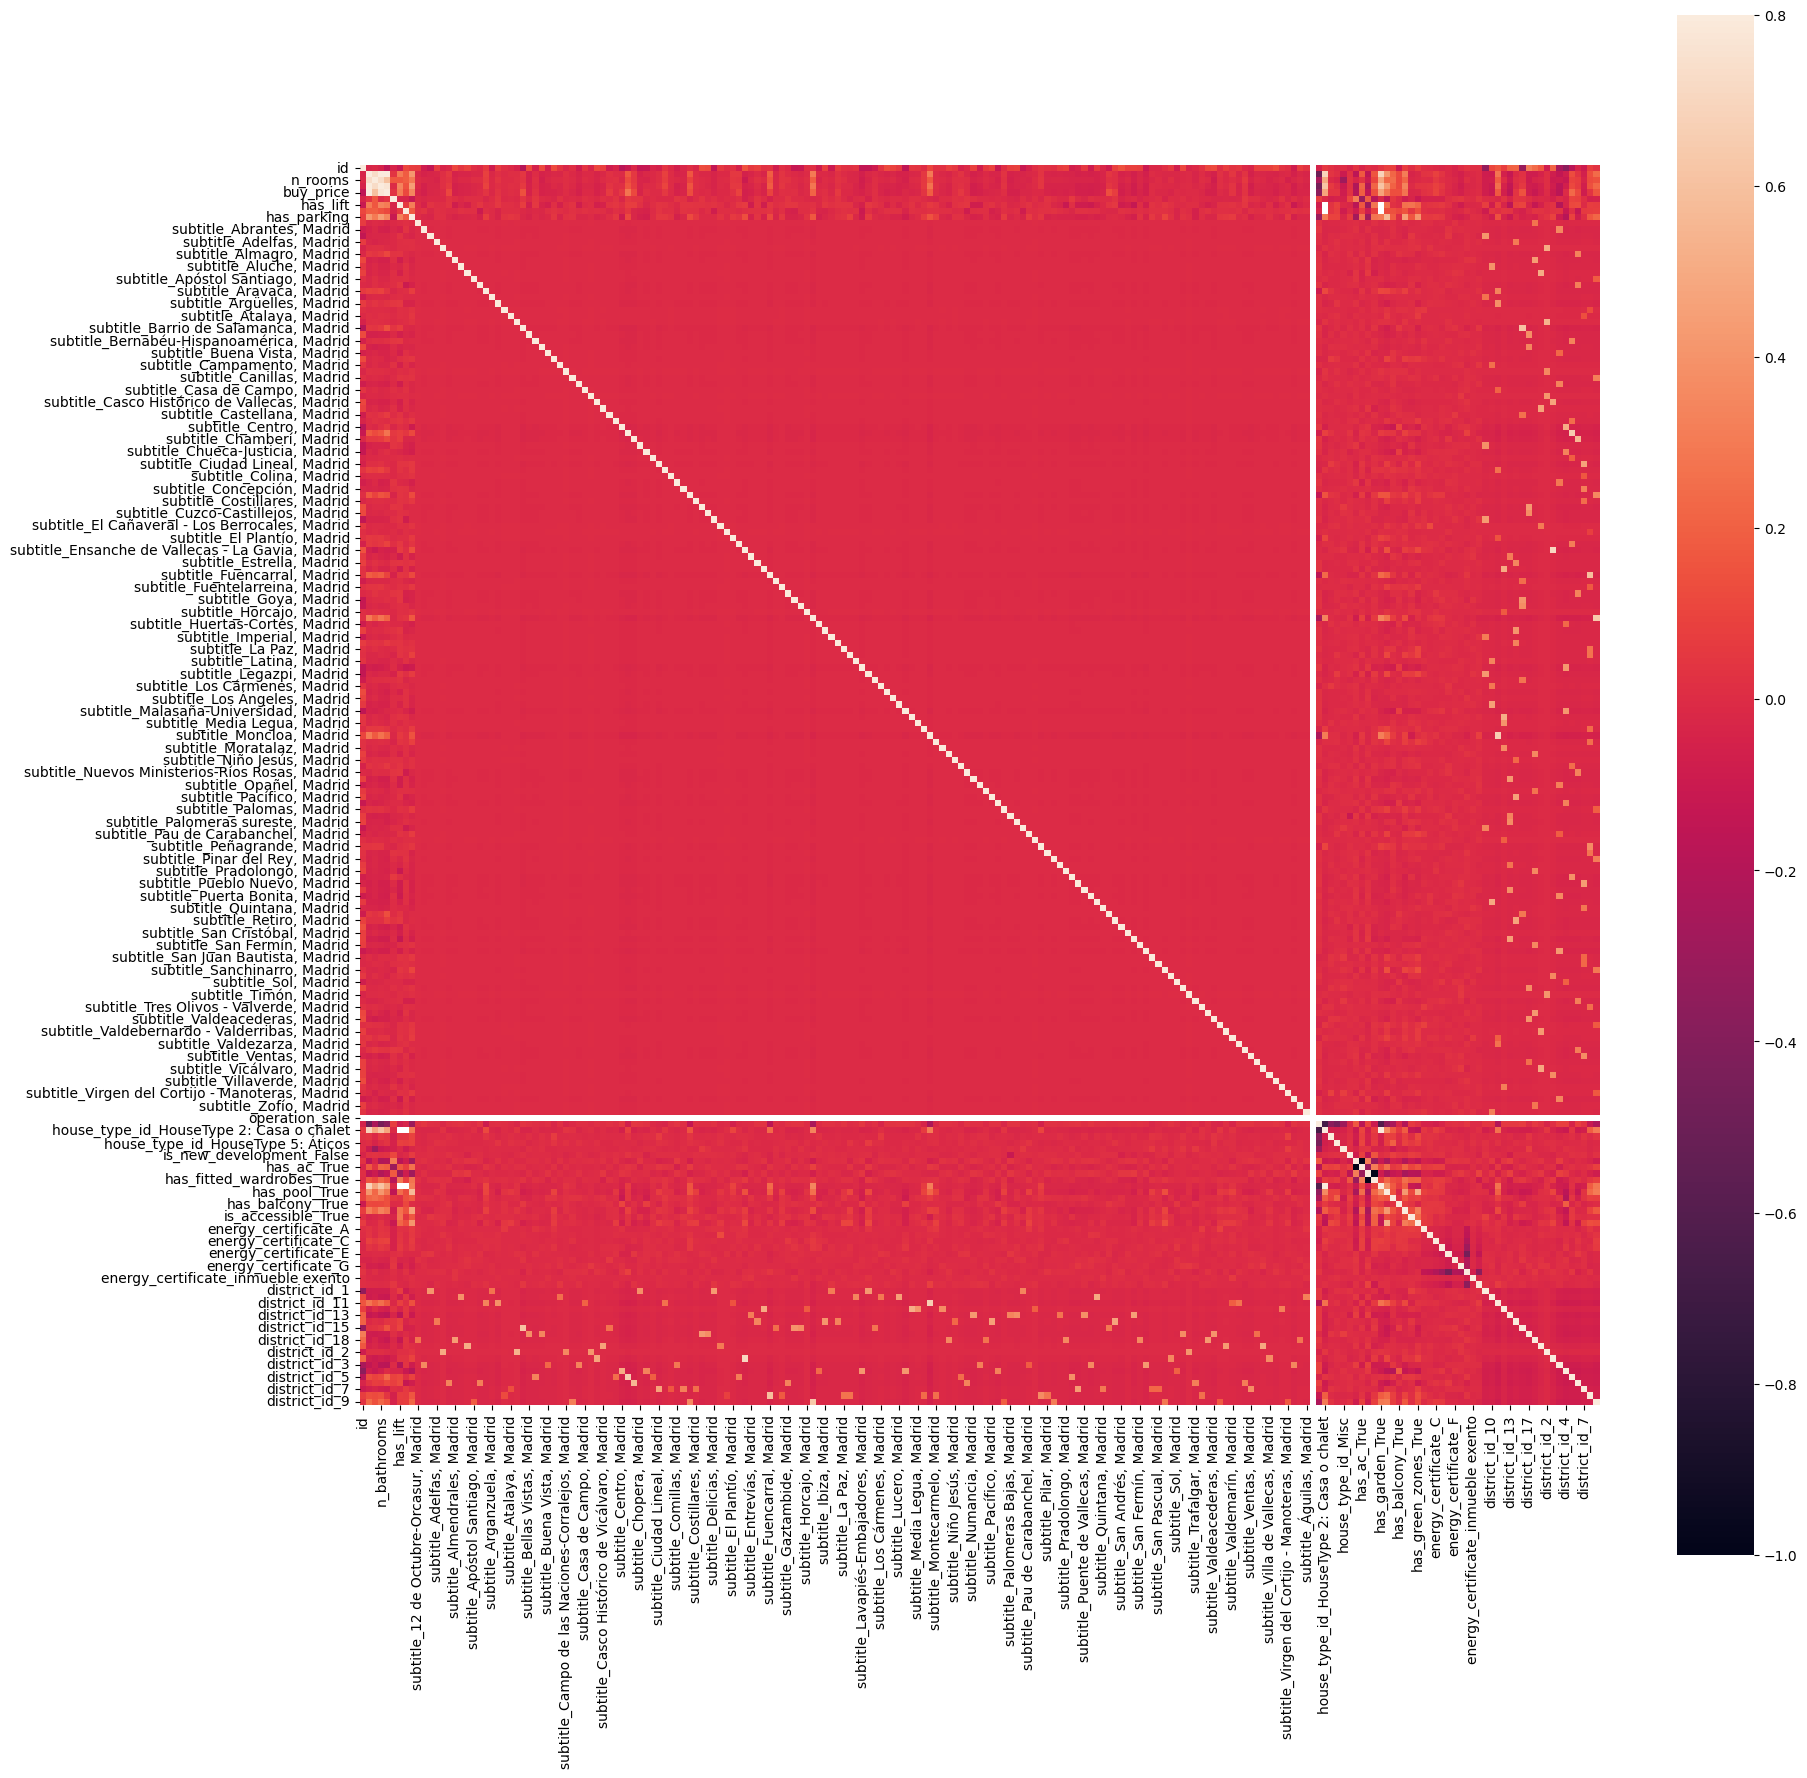

In [201]:
corrmat = dffinal.corr()
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corrmat, vmax=.8, square=True);

In [202]:
corr_matrix=dffinal.corr()
corr_matrix['buy_price'].sort_values(ascending=False)

buy_price                                   1.000000
sq_mt_built                                 0.841513
n_bathrooms                                 0.766726
n_rooms                                     0.603007
house_type_id_HouseType 2: Casa o chalet    0.470029
                                              ...   
district_id_13                             -0.157765
district_id_3                              -0.172651
has_ac_False                               -0.192725
house_type_id_HouseType 1: Pisos           -0.360651
operation_sale                                   NaN
Name: buy_price, Length: 201, dtype: float64

In [203]:
devmode=dftrim['is_new_development'].mode()[0]
dftrim['is_new_development']=dftrim['is_new_development'].fillna(devmode)
print(dftrim['is_new_development'].value_counts())

is_new_development
False    9936
Name: count, dtype: int64


In [204]:
dftrim["house_type_id"].unique()

<ArrowStringArray>
[        'HouseType 1: Pisos',        'HouseType 4: Dúplex',
                       'Misc',        'HouseType 5: Áticos',
 'HouseType 2: Casa o chalet']
Length: 5, dtype: str

In [205]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['house_type_id'] = le.fit_transform(df['house_type_id'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'HouseType 1: Pisos': np.int64(0), 'HouseType 2: Casa o chalet': np.int64(1), 'HouseType 4: Dúplex': np.int64(2), 'HouseType 5: Áticos': np.int64(3), nan: np.int64(4)}


In [206]:
dffinal

,id,sq_mt_built,n_rooms,n_bathrooms,buy_price,is_renewal_needed,has_lift,is_exterior,has_parking,"subtitle_12 de Octubre-Orcasur, Madrid",...,district_id_19,district_id_2,district_id_20,district_id_3,district_id_4,district_id_5,district_id_6,district_id_7,district_id_8,district_id_9
0,21742,64.0,2,1.0,85000,False,0.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,21739,64.0,2,1.0,109900,False,1.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,21738,108.0,2,2.0,260000,False,1.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False
5,21737,126.0,4,2.0,195000,False,0.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False
9,21733,85.0,2,1.0,131400,True,0.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21733,9,267.0,5,3.0,790000,False,NaN,NaN,True,False,...,False,True,False,False,False,False,False,False,False,False
21737,5,78.0,2,2.0,350000,False,1.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False
21738,4,96.0,2,2.0,425000,False,1.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False
21739,3,175.0,4,2.0,680000,False,0.0,1.0,True,False,...,False,True,False,False,False,False,False,False,False,False


In [207]:
df.buy_price

0         85000
3        109900
4        260000
5        195000
9        131400
          ...  
21733    790000
21737    350000
21738    425000
21739    680000
21740    695000
Name: buy_price, Length: 9999, dtype: int64

In [208]:
def prepare(df):
    df=df.drop(columns=['title','subtitle','sq_mt_useful','n_floors','sq_mt_allotment','latitude','longitude','raw_address','is_exact_address_hidden','street_name','street_number','portal','floor','is_floor_under','door','operation','rent_price','rent_price_by_area','is_rent_price_known','buy_price_by_area','is_buy_price_known','has_central_heating','has_individual_heating','are_pets_allowed','is_furnished','is_kitchen_equipped','has_garden','is_renewal_needed','energy_certificate','has_private_parking','has_public_parking','is_parking_included_in_price','parking_price','is_orientation_north','is_orientation_west','is_orientation_south','is_orientation_east'], errors="ignore")
    df=df[df['sq_mt_built'].notna()]
    df=df[df['n_bathrooms'].notna()]
    collist=['has_ac','has_fitted_wardrobes','has_pool','has_terrace','has_balcony','has_storage_room','is_accessible','has_green_zones', 'has_lift', 'is_exterior']
    for col in collist:
        df[col]=df[col].fillna(False)
    mask=(df['is_new_development'].isnull()) & (~df['built_year'].isnull())
    df['is_new_development'][mask]=False
    df.drop(columns='built_year',inplace=True)
    df['is_new_development']=df['is_new_development'].fillna(devmode)
    df['house_type_id']=df['house_type_id'].fillna("Misc")
    df['district_id']=df['neighborhood_id'].copy()
    df.district_id=df.district_id.str.extract(r'(District \d+)')
    df.neighborhood_id=df.neighborhood_id.str.extract(r'(Neighborhood \d+)')
    df.district_id=df.district_id.str.extract(r'(\d+)')
    df.neighborhood_id=df.neighborhood_id.str.extract(r'(\d+)')
    df.drop(columns='neighborhood_id',inplace=True)
    df['has_lift']=pd.to_numeric(df['has_lift'],errors='coerce')
    df['is_exterior']=pd.to_numeric(df['is_exterior'],errors='coerce')
    df=pd.get_dummies(df)

    df=df.drop(columns=['house_type_id_Misc','district_id_21'], errors="ignore")

    y = df["buy_price"]
    X = df.drop(axis=0, columns=["buy_price"])

    
    return X, y

In [209]:
def fill_missing_by_group(df, columns, group_col, group_value=0):
    """
    Fills missing values in specified columns using the mode,
    but only calculated from a specific group (e.g. apartments only).
    
    Parameters:
    -----------
    df          : your DataFrame
    columns     : list of columns to fix (e.g. ['has_lift', 'is_exterior'])
    group_col   : column that defines the group (e.g. 'house_type_id_...')
    group_value : value that identifies the group (default 0 = apartments)
    """
    
    is_group = df[group_col] == group_value  # e.g. is_apartment
    
    for col in columns:
        # Calculate mode from the group only
        mode_value = df.loc[is_group, col].mode()
        
        if mode_value.empty:
            print(f"⚠️  Warning: No mode found for '{col}', skipping.")
            continue
        
        mode_value = mode_value[0]
        
        # Fill missing values within the group only
        missing_in_group = df[col].isnull() & is_group
        df.loc[missing_in_group, col] = mode_value
        
        print(f"✅ '{col}' filled with mode={mode_value} "
              f"({missing_in_group.sum()} values updated)")
    
    return df

In [210]:
from sklearn.model_selection import train_test_split

X, y = prepare(df)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


/var/folders/m6/s_qkv9vs161g9w1bm3hxb69h0000gn/T/ipykernel_22480/2745905961.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df['is_new_development'][mask]=False


In [211]:
X_train.isna().sum()

id                            0
sq_mt_built                   0
n_rooms                       0
n_bathrooms                   0
house_type_id                 0
has_lift                      0
is_exterior                   0
has_parking                   0
is_new_development_False      0
has_ac_False                  0
has_ac_True                   0
has_fitted_wardrobes_False    0
has_fitted_wardrobes_True     0
has_pool_False                0
has_pool_True                 0
has_terrace_False             0
has_terrace_True              0
has_balcony_False             0
has_balcony_True              0
has_storage_room_False        0
has_storage_room_True         0
is_accessible_False           0
is_accessible_True            0
has_green_zones_False         0
has_green_zones_True          0
district_id_1                 0
district_id_10                0
district_id_11                0
district_id_12                0
district_id_13                0
district_id_14                0
district

In [212]:
X_train.isna().sum()

id                            0
sq_mt_built                   0
n_rooms                       0
n_bathrooms                   0
house_type_id                 0
has_lift                      0
is_exterior                   0
has_parking                   0
is_new_development_False      0
has_ac_False                  0
has_ac_True                   0
has_fitted_wardrobes_False    0
has_fitted_wardrobes_True     0
has_pool_False                0
has_pool_True                 0
has_terrace_False             0
has_terrace_True              0
has_balcony_False             0
has_balcony_True              0
has_storage_room_False        0
has_storage_room_True         0
is_accessible_False           0
is_accessible_True            0
has_green_zones_False         0
has_green_zones_True          0
district_id_1                 0
district_id_10                0
district_id_11                0
district_id_12                0
district_id_13                0
district_id_14                0
district

In [217]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X_train)

# Create and train the model
regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
regressor.fit(X_scaled, y_train)

# Predict
y_pred = regressor.predict(sc_X.transform(X_test))

In [219]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

First, models that require a standardized input.

In [223]:
train_x_nonna=X_train.drop(columns=['has_lift','is_exterior'])
test_x_nonna=X_test.drop(columns=['has_lift','is_exterior'])

In [224]:
from sklearn import preprocessing

cols=['sq_mt_built','n_rooms','n_bathrooms']
sca=preprocessing.StandardScaler()
train_x_std=train_x_nonna.copy()
test_x_std=test_x_nonna.copy()
for col in cols:
    train_x_std[col]=sca.fit_transform(train_x_std[[col]])
    test_x_std[col]=sca.transform(test_x_std[[col]])

First, models that require a standardized input.

In [226]:
from sklearn import metrics
from sklearn import model_selection
import math
#standardized
#K-fold means we don't need to split train and test sets
collist=['is_new_development','has_ac','has_fitted_wardrobes','has_pool','has_terrace','has_balcony','has_storage_room','is_accessible','has_green_zones','has_parking']
#for col in collist:
    #x[col]=x[col].astype(int)
scores=['r2','neg_mean_absolute_error','neg_mean_squared_error']
#SVR cut out for now
for model in [DummyRegressor, LinearRegression,KNeighborsRegressor,SVR]:
    if model==SVR:
        cls=model(kernel='linear')
    else:
        cls=model()
    kfold=model_selection.KFold(n_splits=10)
    s=model_selection.cross_validate(cls,train_x_std,y_train,scoring=scores,cv=kfold)
    print(
        f"{model.__name__:22} Fit Time: "
        f"{s['fit_time'].mean():.3f}s  R2: "
        f"{s['test_r2'].mean():.3f}  MAE: "
        f"{s['test_neg_mean_absolute_error'].mean()*-1:.3f}  RMSE: "
        f"{math.sqrt(s['test_neg_mean_squared_error'].mean()*-1):.3f}"
    )

DummyRegressor         Fit Time: 0.003s  R2: -0.002  MAE: 480122.655  RMSE: 723177.982
LinearRegression       Fit Time: 0.010s  R2: 0.790  MAE: 183791.103  RMSE: 332445.170
KNeighborsRegressor    Fit Time: 0.002s  R2: 0.278  MAE: 350958.191  RMSE: 613703.730
SVR                    Fit Time: 6.362s  R2: -0.069  MAE: 405389.218  RMSE: 747290.628


Now, models that can be non-standardized, but cannot have missing values

In [227]:
scores=['r2','neg_mean_absolute_error','neg_mean_squared_error']
for model in [DecisionTreeRegressor, RandomForestRegressor]:
    cls=model()
    kfold=model_selection.KFold(n_splits=10)
    s=model_selection.cross_validate(cls,train_x_nonna,y_train,scoring=scores,cv=kfold)
    mse=s['test_neg_mean_squared_error'].mean()*-1
    rmse=math.sqrt(mse)
    print(
        f"{model.__name__:22} Fit Time: "
        f"{s['fit_time'].mean():.3f}s  R2: "
        f"{s['test_r2'].mean():.3f}  MAE: "
        f"{s['test_neg_mean_absolute_error'].mean()*-1:.3f}  RMSE: "
        f"{rmse:.3f}"
    )

DecisionTreeRegressor  Fit Time: 0.028s  R2: 0.759  MAE: 159314.012  RMSE: 350205.461
RandomForestRegressor  Fit Time: 1.679s  R2: 0.869  MAE: 125178.513  RMSE: 260876.890


Finally, the most flexible ones that allow for anything (nonstandard and missing values)

In [234]:
import regex as re
train_x = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
#missing vals included
for model in [xgb.XGBRegressor, lgb.LGBMRegressor]:
    if model == lgb.LGBMRegressor:
        cls=model(force_row_wise=True, verbose=-1)
    else:
        cls=model()
    kfold=model_selection.KFold(n_splits=10)
    s=model_selection.cross_validate(cls,train_x,y_train,scoring=scores,cv=kfold)
    mse=s['test_neg_mean_squared_error'].mean()*-1
    rmse=math.sqrt(mse)
    print(
        f"{model.__name__:22} Fit Time: "
        f"{s['fit_time'].mean():.3f}s  R2: "
        f"{s['test_r2'].mean():.3f}  MAE: "
        f"{s['test_neg_mean_absolute_error'].mean()*-1:.3f}  RMSE: "
        f"{rmse:.3f}"
    )

XGBRegressor           Fit Time: 0.102s  R2: 0.866  MAE: 127058.784  RMSE: 264565.724
LGBMRegressor          Fit Time: 0.265s  R2: 0.864  MAE: 128459.294  RMSE: 266692.130


Can we get a better score if we limit features to most important ones?

Linear Regression does well, and is fast. I'll use it to do a recursive feature elimination on this to see if there are any unimportant variables in our model.

Index(['id', 'sq_mt_built', 'n_rooms', 'n_bathrooms', 'house_type_id',
       'has_parking', 'is_new_development_False', 'has_ac_False',
       'has_ac_True', 'has_fitted_wardrobes_False',
       'has_fitted_wardrobes_True', 'has_pool_False', 'has_pool_True',
       'has_terrace_False', 'has_terrace_True', 'has_balcony_False',
       'has_balcony_True', 'has_storage_room_False', 'has_storage_room_True',
       'is_accessible_False', 'is_accessible_True', 'has_green_zones_False',
       'has_green_zones_True', 'district_id_1', 'district_id_10',
       'district_id_11', 'district_id_12', 'district_id_13', 'district_id_14',
       'district_id_15', 'district_id_17', 'district_id_18', 'district_id_19',
       'district_id_2', 'district_id_20', 'district_id_3', 'district_id_4',
       'district_id_5', 'district_id_6', 'district_id_7', 'district_id_8',
       'district_id_9'],
      dtype='str')
[5 1 1 1 3 1 6 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 4 1 1 1 1 1
 1 1 1 1 1]
37
[False 

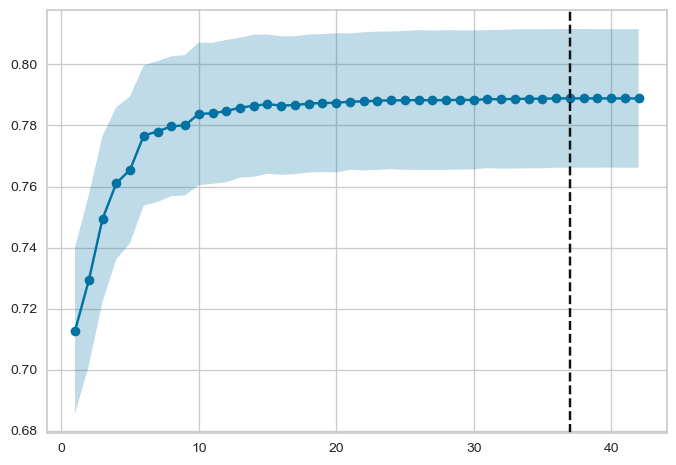

In [235]:
from yellowbrick.features import RFECV
#rfe=RFECV(RandomForestClassifier(n_estimators=50),cv=5)
rfe=RFECV(LinearRegression(),cv=5)
rfe.fit(train_x_std, y_train)
#rfe.fit(train_x_nonna,train_y)
print(train_x_std.columns)
print(rfe.rfe_estimator_.ranking_)
print(rfe.rfe_estimator_.n_features_)
print(rfe.rfe_estimator_.support_)

X-axis — number of features kept

Y-axis — cross-validated R² score

Shaded band — ±1 std deviation across the 5 CV folds

Dashed vertical line — optimal feature count selected = 37

The Wide Confidence Band is a Warning

The shaded region is quite wide (0.68–0.81 at low feature counts), which means high variance across folds — your model is somewhat unstable, especially with few features. It stabilizes after ~15 features.

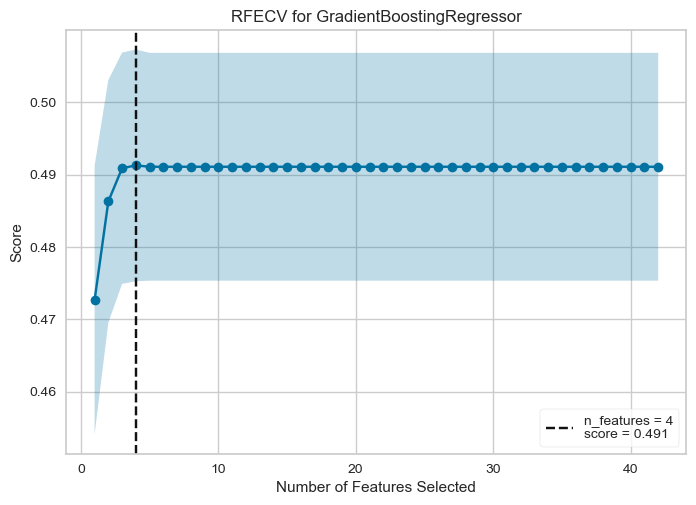

<Axes: title={'center': 'RFECV for GradientBoostingRegressor'}, xlabel='Number of Features Selected', ylabel='Score'>

In [237]:
from sklearn.ensemble import GradientBoostingRegressor

rfe_gb = RFECV(GradientBoostingRegressor(n_estimators=5), cv=3, scoring='r2')
rfe_gb.fit(train_x_std, y_train)
rfe_gb.show()